---

# LSTM - Character-Level Foundation Model

---

In this exercise you'll build a character-level language model using a **Long Short-Term Memory (LSTM)** network trained on Shakespeare text.

**Task:** Given a sequence of characters $x_1, x_2, \dots, x_t$, try to predict the next character. E.g., `Hall` $\rightarrow$ `o`. More formally:

$$P(x_{t+1} \mid x_1, x_2, \dots, x_t)$$

At each timestep $t$, the LSTM processes the current character $x_t$ (one-hot encoded) and maintains a hidden state $h_t$ with dimension $H$ that captures sequence context. The hidden state is then mapped to a probability distribution over the vocabulary `('a', 'b', 'c' , ..., 'y', 'z', 'A', 'B', , ..., ':','.','!', '?')` with size $V$:

$$\hat{y}_t = \text{softmax}(W_y h_t + b_y)$$

Training uses cross-entropy loss:

$$\mathcal{L} = -\sum_{t=1}^{T} \log \hat{y}_t[x_{t+1}]$$

---

## LSTM Theory

---

![lstm_cell.png](lstm_cell.png)

At each timestep $t$, given input $x_t$, previous hidden state $h_{t-1}$, and previous cell state $c_{t-1}$, LSTM computes:

$$\begin{aligned}
f_t &= \sigma(W_f x_t + U_f h_{t-1} + b_f) & \text{(forget gate)} \\
i_t &= \sigma(W_i x_t + U_i h_{t-1} + b_i) & \text{(input gate)} \\
g_t &= \tanh(W_g x_t + U_g h_{t-1} + b_g) & \text{(gate gate)} \\
o_t &= \sigma(W_o x_t + U_o h_{t-1} + b_o) & \text{(output gate)} \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t & \text{(cell state update)} \\
h_t &= o_t \odot \tanh(c_t) & \text{(hidden state)} \\
\end{aligned}$$

Where $\sigma$ is sigmoid and $\odot$ is element-wise multiplication.

**Implementation details:** We stack all gate weights into single matrices:
- `Wx` of shape $(4H, V)$ stacks $W_f, W_i, W_g, W_o$
- `Wh` of shape $(4H, H)$ stacks $U_f, U_i, U_g, U_o$
- `b` of shape $(4H, 1)$ stacks $b_f, b_i, b_g, b_o$

> **⚠️ Important: Gate ordering is f, i, g, o**  
> Rows `[0:H]` = forget, `[H:2H]` = input, `[2H:3H]` = gate, `[3H:4H]` = output.  
> This is the convention used throughout the exercise. All tests rely on this exact ordering!

The output layer uses `Wy` $(V, H)$ and `by` $(V, 1)$ to predict the next character from $h_t$.

---

## Setup

---

In [1]:
import importlib
import lstm_cells
import model
import tests
import train as train_module

Set hyperparameters. Load the dataset.

In [2]:
# Hyperparameters, DON'T CHANGE.
H             = 50     # hidden layer size, higher H results in float32 precision errors for tests cases. You can increase it when all tests pass with H=50.
seq_length    = 25     # number of steps to unroll the LSTM during training
learning_rate = 1.5e-1 # learning rate

# Load shakespeare text data
data = open('shakespeare.txt', 'r').read()
chars = sorted(set(data))
data_size, vocab_size = len(data), len(chars)
print(f'Text has {data_size} characters, {vocab_size} unique.')
char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for i, ch in enumerate(chars)}
print(f'\nVocabulary ({vocab_size} symbols):')
print(''.join([f'  {i:2d}: {repr(ch)}' for i, ch in enumerate(chars)]))

Text has 1115394 characters, 65 unique.

Vocabulary (65 symbols):
   0: '\n'   1: ' '   2: '!'   3: '$'   4: '&'   5: "'"   6: ','   7: '-'   8: '.'   9: '3'  10: ':'  11: ';'  12: '?'  13: 'A'  14: 'B'  15: 'C'  16: 'D'  17: 'E'  18: 'F'  19: 'G'  20: 'H'  21: 'I'  22: 'J'  23: 'K'  24: 'L'  25: 'M'  26: 'N'  27: 'O'  28: 'P'  29: 'Q'  30: 'R'  31: 'S'  32: 'T'  33: 'U'  34: 'V'  35: 'W'  36: 'X'  37: 'Y'  38: 'Z'  39: 'a'  40: 'b'  41: 'c'  42: 'd'  43: 'e'  44: 'f'  45: 'g'  46: 'h'  47: 'i'  48: 'j'  49: 'k'  50: 'l'  51: 'm'  52: 'n'  53: 'o'  54: 'p'  55: 'q'  56: 'r'  57: 's'  58: 't'  59: 'u'  60: 'v'  61: 'w'  62: 'x'  63: 'y'  64: 'z'


### Look at the text

In [3]:
print("...\n", data[1000:1500], "\n...")

...
 Second Citizen:
Would you proceed especially against Caius Marcius?

All:
Against him first: he's a very dog to the commonalty.

Second Citizen:
Consider you what services he has done for his country?

First Citizen:
Very well; and could be content to give him good
report fort, but that he pays himself with being proud.

Second Citizen:
Nay, but speak not maliciously.

First Citizen:
I say unto you, what he hath done famously, he did
it to that end: though soft-conscienced men can be
content to  
...


---

# LSTM Cell

---


## **Task:**

Each text character needs a vector representation.
Implement a function that creates a one-hot encoded column vector of shape `(vocab_size, 1)` with a `1.0` at position `ix`.

Implement `one_hot_encode` in `lstm_cells.py`.

Run the cell below.

In [4]:
importlib.reload(lstm_cells)
tests.test_one_hot_encode(lstm_cells.one_hot_encode)

✅ PASS: one_hot_encode is correct.


True

---

## **Task:**

Implement the sigmoid activation and its derivative.

Implement `sigmoid` and `sigmoid_deriv` in `lstm_cells.py`.

Run the cell below.

In [5]:
importlib.reload(lstm_cells)
tests.test_sigmoid(lstm_cells.sigmoid)
tests.test_sigmoid_deriv(lstm_cells.sigmoid,lstm_cells.sigmoid_deriv)

✅ PASS: sigmoid is correct.
✅ PASS: sigmoid_deriv is correct (matches numerical gradient).


True

---

## **Task:**

Implement a **single LSTM cell** forward step. This means **one** timestep.

Implement `lstm_cell_forward` in `lstm_cells.py`.

> **⚠️ Check gate ordering!** We store gates in `Wx`, `Wh`, `b` in the order **[f, i, g, o]**. If you swap gate positions, the tests might fail!

Run the cell below.

In [6]:
importlib.reload(lstm_cells)
tests.test_lstm_cell_forward(lstm_cells.lstm_cell_forward, H=H)

✅ PASS: h has correct shape (50, 1)
✅ PASS: c has correct shape (50, 1)
✅ PASS: h matches reference (max diff 6.24e-08)
✅ PASS: c matches reference (max diff 1.14e-07)
✅ PASS: cache contains all required keys

🎉 lstm_cell_forward is correct!


True

---

## **Task:**

Implement backprop for a **single LSTM cell** backward step. This means **one** timestep.

Implement `lstm_cell_backward` in `lstm_cells.py`.

Run the cell below.

In [7]:
importlib.reload(lstm_cells)
tests.test_lstm_cell_backward(lstm_cells.lstm_cell_forward, lstm_cells.lstm_cell_backward, H=H)

✅ PASS: dWx matches reference (max error 4.47e-08)
✅ PASS: dWh matches reference (max error 1.12e-08)
✅ PASS: db matches reference (max error 4.47e-08)
✅ PASS: dh_prev matches reference (max error 4.77e-07)
✅ PASS: dc_prev matches reference (max error 2.98e-08)

🎉 lstm_cell_backward is correct!


True

---

# LSTM Model

---

## **Task:**

Initialize the LSTM network weights. The initalization scheme is given in the function's doc string.

Implement `init_model` in `model.py`.

Run the cell below.

In [8]:
importlib.reload(model)
tests.test_init_model(model.init_model, vocab_size, H)

✅ PASS: Wx shape (200, 65)
✅ PASS: Wh shape (200, 50)
✅ PASS: b shape (200, 1)
✅ PASS: Wy shape (65, 50)
✅ PASS: by shape (65, 1)
✅ PASS: b is all zeros
✅ PASS: by is all zeros
✅ PASS: Wx max|val| = 4.34e-02 (small)
✅ PASS: Wh max|val| = 3.79e-02 (small)
✅ PASS: Wy max|val| = 3.77e-02 (small)
✅ PASS: Wx.std() = 1.00e-02 ≈ 0.01
✅ PASS: Wh.std() = 1.01e-02 ≈ 0.01
✅ PASS: Wy.std() = 1.01e-02 ≈ 0.01

🎉 init_model looks good!


True

---

## **Task:**

Unroll the LSTM over a full time sequence:

Implement `forward_pass` in `model.py`.

Hints:
- Loop over timesteps, using `one_hot_encode` and `lstm_cell_forward` at each step
- Accumulate cross-entropy loss summation (target at timestep $t$ is `inputs[(t+1) % T]`)
- Cache everything needed for the backward pass

Run the cell below.

In [9]:
importlib.reload(lstm_cells)
importlib.reload(model)
inputs = [char_to_ix[ch] for ch in data[:seq_length]]
tests.test_forward_pass(model.forward_pass, model.init_model, vocab_size, H, seq=inputs)


🔍 Comparing your forward_pass loss against PyTorch reference ...
✅ PASS: loss = 115.566809, reference = 115.566809 (within tol=1e-05)
✅ PASS: cache contains 25 cell caches for 25 timesteps

🎉 forward_pass looks correct!


True

---

## **Task:**

Apply Backpropagation through time (BPTT).

Implement `backward_pass` in `model.py`.

Hints:
- Loop **backwards** through timesteps
- Use `lstm_cell_backward` to get cell-level gradients and propagate them to previous timesteps

Run the cell below.

In [10]:
importlib.reload(lstm_cells)
importlib.reload(model)
inputs = [char_to_ix[ch] for ch in data[:seq_length]]
tests.test_backward_pass(model.backward_pass, model.forward_pass, model.init_model, vocab_size, H, seq=inputs)

✅ PASS: dWx shape (200, 65)
✅ PASS: dWh shape (200, 50)
✅ PASS: dWy shape (65, 50)
✅ PASS: db shape (200, 1)
✅ PASS: dby shape (65, 1)
✅ PASS: h_last shape (50, 1)
✅ PASS: c_last shape (50, 1)
✅ PASS: dWx gradients match (max error 1.43e-06)
✅ PASS: dWh gradients match (max error 1.56e-06)
✅ PASS: dWy gradients match (max error 1.04e-06)
✅ PASS: db gradients match (max error 3.46e-06)
✅ PASS: dby gradients match (max error 4.02e-07)
✅ PASS: h_last matches reference (max error 4.40e-07)
✅ PASS: c_last matches reference (max error 9.24e-07)

🎉 All gradient checks passed! Your backward_pass matches PyTorch autograd.


True

---

## Training

---

Done! Let's train the LSTM. 

During training, the LSTM will generate some text (auto-regressively like LLMs) to double-check if your model learns anything useful.

- You should reach a loss of ~51.0 or lower.
- At the end, LSTM outputs will still look a bit weird but you can identify english words, names and other shakespeare characteristics.

Run the cell below.


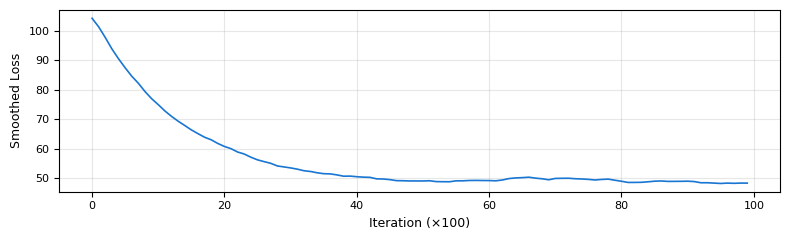

In [11]:
importlib.reload(lstm_cells)
importlib.reload(model)
importlib.reload(train_module)

Wx, Wh, b, Wy, by = model.init_model(vocab_size, H)

loss_history = train_module.train(
    data, vocab_size, char_to_ix, ix_to_char,
    model_params=(Wx, Wh, b, Wy, by),
    seq_length=seq_length, H=H, learning_rate=learning_rate,
    forward_pass=model.forward_pass,
    backward_pass=model.backward_pass,
    max_iters=10000
)